In [31]:
import cv2
import os
import ipywidgets as widgets
from IPython.display import display
import glob
import numpy as np
import re
import librosa
import matplotlib.pyplot as plt
from scipy import signal
from moviepy import VideoFileClip
import threading
import time


## 1. Offset Computation

In [106]:
# --- 1. Configuration ---
LEFT_VIDEO_PATH = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\CLEAN_CODE\data\raw\calibration-v2\left_videos\ground_truth_3.MOV'   # Replace with your left video path
RIGHT_VIDEO_PATH = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\CLEAN_CODE\data\raw\calibration-v2\right_videos\ground_truth_3.MOV'  # Replace with your right video path

In [107]:
# --- 2. Initialization ---
cap_L = cv2.VideoCapture(LEFT_VIDEO_PATH)
cap_R = cv2.VideoCapture(RIGHT_VIDEO_PATH)

frames_L = int(cap_L.get(cv2.CAP_PROP_FRAME_COUNT))
frames_R = int(cap_R.get(cv2.CAP_PROP_FRAME_COUNT))
fps_L = cap_L.get(cv2.CAP_PROP_FPS)

if frames_L == 0 or frames_R == 0:
    raise ValueError("Error: Could not load one or both videos. Please check the file paths.")

# Calculate playback delay (approximate)
play_delay = 1.0 / fps_L if fps_L > 0 else 0.033

In [108]:
# --- 3. UI Components ---
img_widget_L = widgets.Image(format='jpeg', width=480)
img_widget_R = widgets.Image(format='jpeg', width=480)

slider_L = widgets.IntSlider(min=0, max=frames_L-1, step=1, value=0, description='Frame L:', layout=widgets.Layout(width='480px'))
slider_R = widgets.IntSlider(min=0, max=frames_R-1, step=1, value=0, description='Frame R:', layout=widgets.Layout(width='480px'))

play_btn = widgets.ToggleButton(value=False, description='▶️ Play Sync', button_style='info', layout=widgets.Layout(width='200px'))

info_label = widgets.HTML(value="<b>Offset:</b> 0 frames | <b>Time Shift:</b> 0.000s")

In [109]:
# --- 4. Logic ---
def get_jpeg_frame(cap, frame_idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if ret:
        _, jpeg = cv2.imencode('.jpg', frame)
        return jpeg.tobytes()
    return b''

def update_offset():
    offset = slider_R.value - slider_L.value
    time_offset = offset / fps_L if fps_L > 0 else 0
    
    if offset > 0:
        direction = "Right video started EARLIER. (Right is ahead in frames)"
    elif offset < 0:
        direction = "Left video started EARLIER. (Left is ahead in frames)"
    else:
        direction = "Perfectly synced at these frames."
        
    info_label.value = f"<b>Offset:</b> {offset} frames (Right - Left) | <b>Time Shift:</b> {time_offset:.3f}s<br><i>{direction}</i>"

def on_slider_L_change(change):
    img_widget_L.value = get_jpeg_frame(cap_L, change['new'])
    update_offset()

def on_slider_R_change(change):
    img_widget_R.value = get_jpeg_frame(cap_R, change['new'])
    update_offset()

# --- NEW: Background Playback Threading ---
def play_video_thread():
    """Runs in the background to increment sliders automatically."""
    while play_btn.value:
        next_L = slider_L.value + 1
        next_R = slider_R.value + 1
        
        # Stop playing if either video hits the end
        if next_L >= frames_L or next_R >= frames_R:
            play_btn.value = False
            break
            
        # Updating the sliders automatically triggers the get_jpeg_frame functions
        slider_L.value = next_L
        slider_R.value = next_R
        
        # Pause briefly to simulate framerate
        time.sleep(play_delay)

def on_play_toggle(change):
    """Fired when the Play/Pause button is clicked."""
    if change['new']: # Button was toggled ON
        play_btn.description = '⏸️ Pause'
        play_btn.button_style = 'warning'
        # Kick off the background thread
        thread = threading.Thread(target=play_video_thread)
        thread.start()
    else: # Button was toggled OFF
        play_btn.description = '▶️ Play Sync'
        play_btn.button_style = 'info'

# Bind components
slider_L.observe(on_slider_L_change, names='value')
slider_R.observe(on_slider_R_change, names='value')
play_btn.observe(on_play_toggle, names='value')

# Initialize first frames
img_widget_L.value = get_jpeg_frame(cap_L, 0)
img_widget_R.value = get_jpeg_frame(cap_R, 0)

In [110]:
# --- 5. Layout and Display ---
left_box = widgets.VBox([widgets.HTML("<center><b>Left Camera View</b></center>"), img_widget_L, slider_L])
right_box = widgets.VBox([widgets.HTML("<center><b>Right Camera View</b></center>"), img_widget_R, slider_R])

# We wrap the play button in an HBox to easily center it beneath the videos
play_box = widgets.HBox([play_btn], layout=widgets.Layout(justify_content='center', margin='10px 0px 10px 0px'))

ui = widgets.VBox([
    widgets.HBox([left_box, right_box]),
    play_box,
    info_label
])

display(ui)

## Alternative method : Observing Amplitude Peaks in Video Audio

In [111]:
# --- 1. Configuration ---
# How many seconds of audio to analyze? 
ANALYZE_SECONDS = 240 
SAMPLE_RATE = 48000 # Standard video audio sample rate

In [112]:

print("Extracting audio to .wav files...")

# Extract Left Audio
clip_L = VideoFileClip(LEFT_VIDEO_PATH)
clip_L.audio.write_audiofile('left_audio.wav', fps=48000, logger=None)
clip_L.close()

# Extract Right Audio
clip_R = VideoFileClip(RIGHT_VIDEO_PATH)
clip_R.audio.write_audiofile('right_audio.wav', fps=48000, logger=None)
clip_R.close()

print("Extraction complete!")

Extracting audio to .wav files...
Extraction complete!


In [113]:
# --- 2. Load Audio Signals ---
print("Extracting audio tracks. This may take a moment...")
# librosa automatically converts stereo audio to mono for easier mathematical comparison
audio_L, sr = librosa.load('left_audio.wav', sr=SAMPLE_RATE, duration=ANALYZE_SECONDS)
audio_R, _ = librosa.load('right_audio.wav', sr=SAMPLE_RATE, duration=ANALYZE_SECONDS)

# Normalize audio to prevent volume differences from skewing the math
audio_L = audio_L / np.max(np.abs(audio_L))
audio_R = audio_R / np.max(np.abs(audio_R))

Extracting audio tracks. This may take a moment...


In [114]:
# --- 3. Compute Cross-Correlation ---
print("Calculating precise temporal offset...")
# Cross-correlation mathematically slides the arrays against each other to find the peak match
correlation = signal.correlate(audio_L, audio_R, mode='full')
lags = signal.correlation_lags(audio_L.size, audio_R.size, mode='full')

# Find the exact sample where the audio tracks align perfectly
best_lag_index = np.argmax(correlation)
lag_samples = lags[best_lag_index]

# Convert the sample offset back into real time (seconds)
offset_seconds = lag_samples / sr

# Calculate the exact frame offset equivalent (assuming a 30fps video)
fps = 30.0 
offset_frames = offset_seconds * fps


Calculating precise temporal offset...


In [115]:
# --- 4. Print Results ---
print("\n" + "="*40)
if offset_seconds > 0:
    print(f"Left video started EARLIER by: {offset_seconds:.4f} seconds")
elif offset_seconds < 0:
    print(f"Right video started EARLIER by:  {abs(offset_seconds):.4f} seconds")
else:
    print("Videos are perfectly synchronized down to the sample.")

print(f"Equivalent visual frame shift:  {offset_frames:.2f} frames")
print("="*40 + "\n")


Right video started EARLIER by:  13.4770 seconds
Equivalent visual frame shift:  -404.31 frames



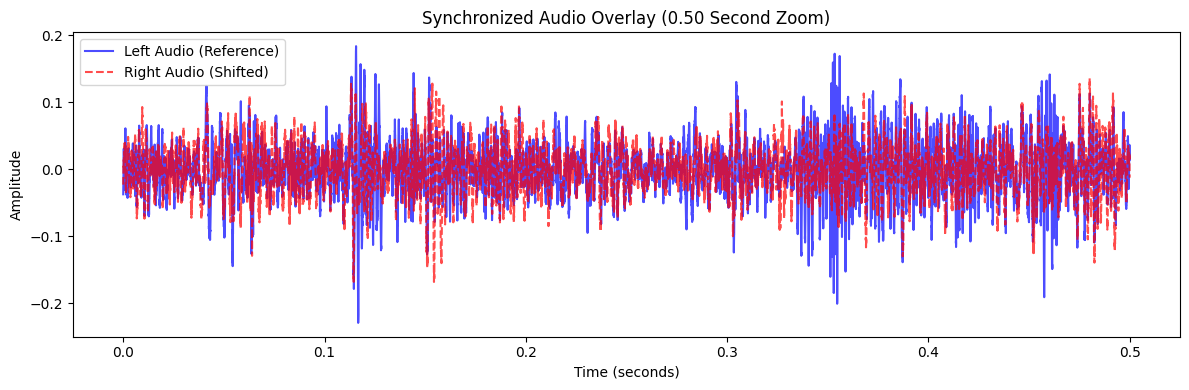

In [116]:
# --- 5. Visual Proof  ---
# Shift the Right audio array to align with the Left based on our findings
if lag_samples > 0:
    aligned_R = np.pad(audio_R, (lag_samples, 0))[:len(audio_L)]
    aligned_L = audio_L
else:
    aligned_L = np.pad(audio_L, (abs(lag_samples), 0))[:len(audio_R)]
    aligned_R = audio_R

# --- THE FIX: Dynamic Zoom Window ---
zoom_samples = int(0.5 * sr) 
actual_length = min(len(aligned_L), len(aligned_R))

# If your entire video is shorter than 0.5 seconds, zoom out to show the whole thing
if actual_length < zoom_samples:
    zoom_samples = actual_length
    start_idx = 0
else:
    # Pick a safe spot exactly in the middle of whatever audio exists
    start_idx = int((actual_length - zoom_samples) / 2)

end_idx = start_idx + zoom_samples

# Create the X-axis timeline dynamically based on the safe zoom samples
time_axis = np.linspace(0, zoom_samples / sr, zoom_samples)

plt.figure(figsize=(12, 4))
plt.title(f"Synchronized Audio Overlay ({zoom_samples / sr:.2f} Second Zoom)")
plt.plot(time_axis, aligned_L[start_idx:end_idx], label="Left Audio (Reference)", color='blue', alpha=0.7)
plt.plot(time_axis, aligned_R[start_idx:end_idx], label="Right Audio (Shifted)", color='red', alpha=0.7, linestyle='dashed')
plt.ylabel("Amplitude")
plt.xlabel("Time (seconds)")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Frame Extraction for Calibration based on Offset

In [118]:
# Frame offset :NB: 
# 2 Meters (30003 and 30229) = 167 frames difference between the two videos. (Right first)
# 2 Meters (30004 and 30230) = -112 frames difference between the two videos. (Left first)
# GT (30009 and 30235) = 155 frames difference between the two videos. (Right first)

# If the Right video started EARLIER, Right is ahead: Left starts at 0, Right starts at 167.
# If the Left video started EARLIER, Left is ahead: Left starts at 167, Right starts at 0.
START_FRAME_LEFT = 0
START_FRAME_RIGHT = 404


DISTANCE_PREFIX = 'ground_truth_3' # Change 'X' to the actual distance

# --- Parent Folder and Capture Interval ---
CAPTURE_INTERVAL = 15 # Saves 1 frame every 15 frames (about 1 pair per 2 second for a 30fps video)


In [123]:
# --- 1. Configuration ---
PARENT_FOLDER = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2"

# Input Folders
LEFT_IN_DIR = os.path.join(PARENT_FOLDER, f"{DISTANCE_PREFIX}-Left-Frames")
RIGHT_IN_DIR = os.path.join(PARENT_FOLDER, f"{DISTANCE_PREFIX}-Right-Frames")

# Output Folders: 

# Ground Truth frames
LEFT_OUT_DIR = os.path.join(r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\selected_ground_truth", "Left")
RIGHT_OUT_DIR = os.path.join(r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\selected_ground_truth", "Right")

#Calibration frames
# LEFT_OUT_DIR = os.path.join(r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\selected_calibration", "Left")
# RIGHT_OUT_DIR = os.path.join(r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2\selected_calibration", "Right")

os.makedirs(LEFT_OUT_DIR, exist_ok=True)
os.makedirs(RIGHT_OUT_DIR, exist_ok=True)

In [ ]:

# --- 2. Setup Directories ---
# Using os.path.join nests the subfolders inside the parent folder
left_dir = os.path.join(PARENT_FOLDER, f"{DISTANCE_PREFIX}-Meters-Left-Frames")
right_dir = os.path.join(PARENT_FOLDER, f"{DISTANCE_PREFIX}-Meters-Right-Frames")

os.makedirs(left_dir, exist_ok=True)
os.makedirs(right_dir, exist_ok=True)

# --- 3. Video Initialization ---
cap_L = cv2.VideoCapture(LEFT_VIDEO_PATH)
cap_R = cv2.VideoCapture(RIGHT_VIDEO_PATH)

cap_L.set(cv2.CAP_PROP_POS_FRAMES, START_FRAME_LEFT)
cap_R.set(cv2.CAP_PROP_POS_FRAMES, START_FRAME_RIGHT)

current_frame = 0
saved_count = 0
print(f"Extracting aligned frames into '{PARENT_FOLDER}'...")

# --- 4. Extraction Loop ---
while True:
    ret_L, frame_L = cap_L.read()
    ret_R, frame_R = cap_R.read()

    if not ret_L or not ret_R:
        break

    # Only save the frame if it matches our interval
    if current_frame % CAPTURE_INTERVAL == 0:
        saved_count += 1
        
        filename_L = os.path.join(left_dir, f"{DISTANCE_PREFIX}-Meters-Left-Frame-{saved_count}.jpg")
        filename_R = os.path.join(right_dir, f"{DISTANCE_PREFIX}-Meters-Right-Frame-{saved_count}.jpg")

        cv2.imwrite(filename_L, frame_L)
        cv2.imwrite(filename_R, frame_R)

    current_frame += 1

# --- 5. Cleanup ---
cap_L.release()
cap_R.release()

print(f"Done! Extracted {saved_count} perfectly synchronized stereo pairs.")

Extracting aligned frames into 'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\DATASET FOR STEREO CALIBRATION\CUSTOM CAMERA CALIBRATION DATASET V2'...
Done! Extracted 92 perfectly synchronized stereo pairs.


In [124]:
#  Load and Sort Files 
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

left_images = sorted(glob.glob(os.path.join(LEFT_IN_DIR, '*.jpg')), key=natural_sort_key)
right_images = sorted(glob.glob(os.path.join(RIGHT_IN_DIR, '*.jpg')), key=natural_sort_key)

if not left_images or not right_images:
    raise ValueError("No images found. Check your folder paths!")

total_pairs = len(left_images)
print(f"Loaded {total_pairs} pairs for review.")
print("CONTROLS:")
print("  [s]           : Save this pair and advance")
print("  [Right Arrow] : Skip to next pair (or Space / 'd')")
print("  [Left Arrow]  : Go back to previous pair (or 'a')")
print("  [q]           : Quit the review tool")

Loaded 92 pairs for review.
CONTROLS:
  [s]           : Save this pair and advance
  [Right Arrow] : Skip to next pair (or Space / 'd')
  [Left Arrow]  : Go back to previous pair (or 'a')
  [q]           : Quit the review tool


In [125]:
# --- 3. Review Loop (Bidirectional) ---
saved_count = 0
idx = 0
window_name = "Stereo Review (Click this window to use keys)"

cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

while idx < total_pairs:
    img_left_path = left_images[idx]
    img_right_path = right_images[idx]
    
    # Read the images
    img_L = cv2.imread(img_left_path)
    img_R = cv2.imread(img_right_path)
    
    # Concatenate them side-by-side
    combined = np.hstack((img_L, img_R))
    
    # Add a visual frame counter to the top-left corner
    overlay_text = f"Frame: {idx + 1} / {total_pairs} | Total Saved: {saved_count}"
    cv2.putText(combined, overlay_text, (50, 80), cv2.FONT_HERSHEY_SIMPLEX, 
                2, (0, 255, 0), 4, cv2.LINE_AA)
    
    # Resize for the display window
    scale_percent = 50 
    width = int(combined.shape[1] * scale_percent / 100)
    height = int(combined.shape[0] * scale_percent / 100)
    resized_view = cv2.resize(combined, (width, height), interpolation=cv2.INTER_AREA)
    
    # Show the image
    cv2.imshow(window_name, resized_view)
    
    # Use waitKeyEx to capture extended keys like arrows
    key = cv2.waitKeyEx(0)
    
    if key == ord('s'):
        filename_L = os.path.basename(img_left_path)
        filename_R = os.path.basename(img_right_path)
        
        # Only increment saved_count if we haven't saved this exact file before
        if not os.path.exists(os.path.join(LEFT_OUT_DIR, filename_L)):
            saved_count += 1
            
        cv2.imwrite(os.path.join(LEFT_OUT_DIR, filename_L), img_L)
        cv2.imwrite(os.path.join(RIGHT_OUT_DIR, filename_R), img_R)
        
        print(f"Saved pair {idx + 1}: {filename_L} & {filename_R} (Total Saved: {saved_count})")
        idx += 1 # Auto-advance after saving
        
    elif key == ord('q') or key == 27: # 27 is Escape
        print("Review cancelled by user.")
        break
        
    # Left Arrow (Windows: 2424832, Linux: 65361, Mac: 2 or 63234) or 'a'
    elif key in [2424832, 65361, 2, 63234, ord('a')]:
        idx = max(0, idx - 1) # Prevent going below index 0
        
    # Right Arrow (Windows: 2555904, Linux: 65363, Mac: 3 or 63235), Space, or 'd'
    elif key in [2555904, 65363, 3, 63235, ord('d'), ord(' ')]:
        idx += 1
        
    else:
        # Ignore unsupported keys
        pass

# --- 4. Cleanup ---
cv2.destroyAllWindows()
cv2.waitKey(1) 

print(f"Done! You have {saved_count} perfect pairs in your SELECTED-FRAMES folders.")

Saved pair 87: ground_truth_3-Left-Frame-87.jpg & ground_truth_3-Meters-Right-Frame-87.jpg (Total Saved: 1)
Done! You have 1 perfect pairs in your SELECTED-FRAMES folders.
